In [5]:
df_clean = pd.read_csv("processed.csv")
print(df_clean.shape)
df_clean.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [6]:
print("Colonnes:", df.columns.tolist())
print("\nValeurs uniques Loan_Status:", df["Loan_Status"].unique())
print("\nValeurs manquantes:\n", df.isnull().sum())

Colonnes: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Valeurs uniques Loan_Status: [1 0]

Valeurs manquantes:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


# Bank-Logic — EDA Report
## Dev B | Exploratory Data Analysis on Cleaned Dataset

This notebook explores the processed.csv file cleaned by Dev A.
The goal is to extract visual insights that explain what factors 
influence loan approval decisions.

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("processed.csv")
sns.set_theme(style="whitegrid", palette="muted")
print("Dataset ready:", df.shape)

Dataset ready: (614, 13)


## Chart 1 — Credit History vs Loan Approval

We start with the most important question:
does having a credit history actually increase 
your chances of getting a loan approved?

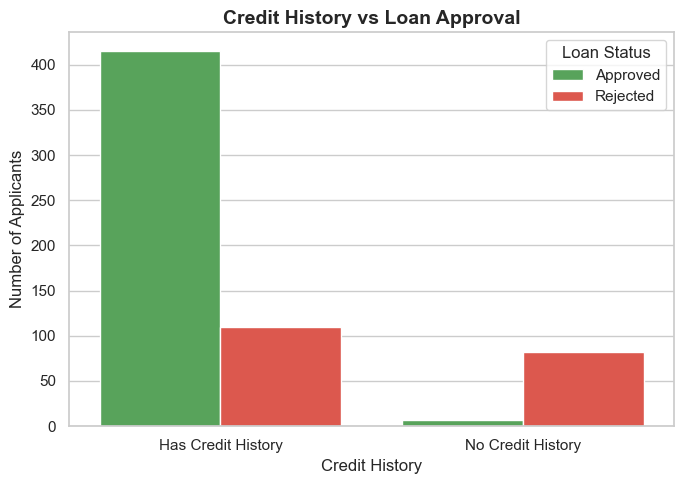

In [9]:
df["Credit_History_Label"] = df["Credit_History"].map({
    1.0: "Has Credit History",
    0.0: "No Credit History"
})

df["Loan_Status_Label"] = df["Loan_Status"].map({
    1: "Approved",
    0: "Rejected"
})

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="Credit_History_Label",
    hue="Loan_Status_Label",
    palette={"Approved": "#4CAF50", "Rejected": "#F44336"}
)
plt.title("Credit History vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status")
plt.tight_layout()
plt.show()

### 💡 Insight 1
Applicants WITH a credit history are approved at a dramatically 
higher rate than those without one.

This is the single strongest predictor in the entire dataset.
A clean repayment history tells the bank: "this person has 
borrowed money before and paid it back."

➡️ Recommendation for Dev A: Credit_History must be kept 
as a top priority feature when building the ML model.

## Chart 2 — Total Household Income vs Loan Approval

Does earning more money mean you are more likely 
to get approved? Let's find out.

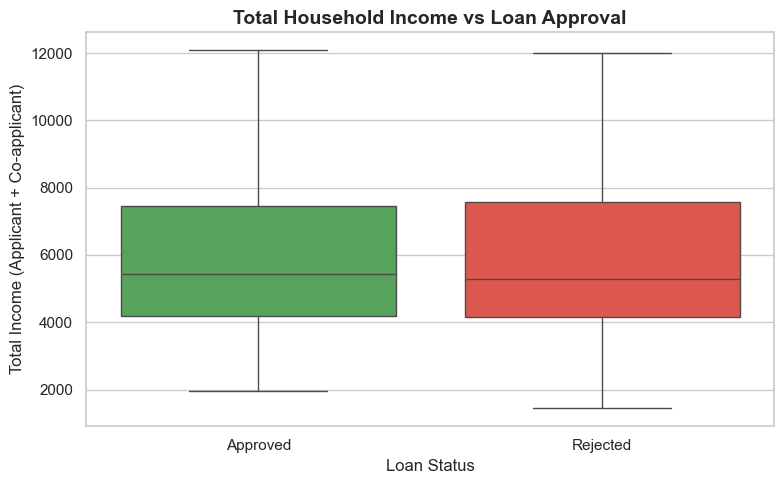

In [10]:
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Loan_Status_Label",
    y="TotalIncome",
    hue="Loan_Status_Label",
    palette={"Approved": "#4CAF50", "Rejected": "#F44336"},
    showfliers=False
)
plt.title("Total Household Income vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Loan Status")
plt.ylabel("Total Income (Applicant + Co-applicant)")
plt.tight_layout()
plt.show()


### 💡 Insight 2
Approved and rejected applicants have surprisingly similar 
income levels. The two boxes are almost the same height.

This tells us that income alone is NOT enough to predict 
loan approval. A high earner with no credit history can 
still get rejected.

➡️ Recommendation for Dev A: TotalIncome is a useful 
engineered feature but should not be used alone — 
always combine it with Credit_History.

## Chart 3 — Property Area vs Loan Approval

Does the location of the property affect 
the bank's decision?

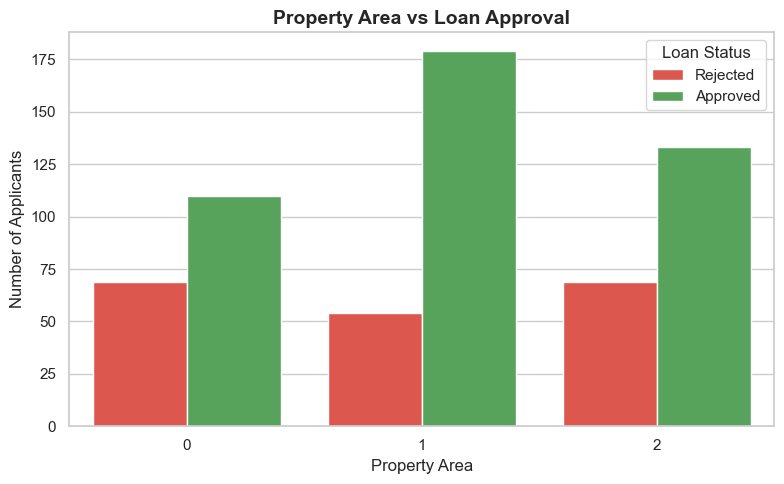

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status_Label",
    palette={"Approved": "#4CAF50", "Rejected": "#F44336"}
)
plt.title("Property Area vs Loan Approval", fontsize=14, fontweight="bold")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status")
plt.tight_layout()
plt.show()

### 💡 Insight 3
Semiurban properties have the highest approval rate 
by a clear margin. Rural properties have the worst 
approval rate — the gap between approved and rejected 
is the smallest there.

Banks see Semiurban properties as growing in value 
and easier to recover if the loan defaults.

➡️ Recommendation for Dev A: Property_Area is a 
meaningful feature — keep it in the model.

## Summary — Key Findings

| # | Finding | Business Meaning |
|---|---------|-----------------|
| 1 | Credit History = strongest predictor | Past behavior predicts future behavior |
| 2 | Income alone = weak predictor | Creditworthiness matters more than salary |
| 3 | Semiurban = highest approval rate | Property location affects bank risk assessment |

**Top recommendation for the ML model:**
The three most important features to prioritize are:
Credit_History, Property_Area, and TotalIncome (engineered).